Assigned cluster labels: [1 1 1 0 0 0]


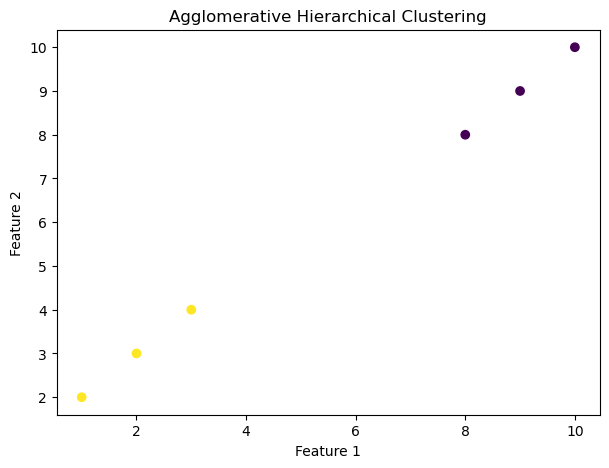

Cluster 1:
[[ 1  2]
 [ 8  8]
 [ 9  9]
 [10 10]]

Cluster 2:
[[2 3]
 [3 4]]



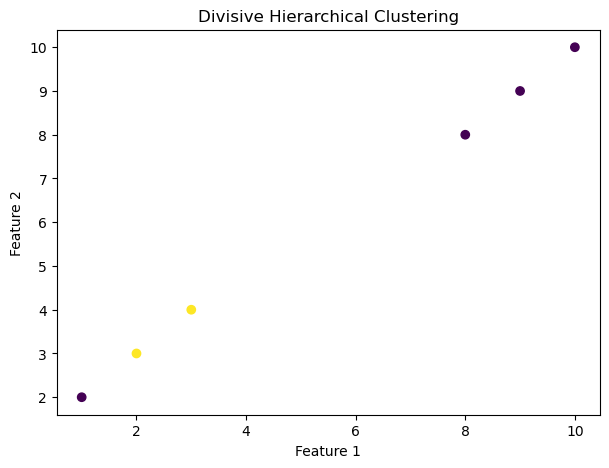

In [5]:

# ============================================================
# 1. Agglomerative Hierarchical Clustering
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

# Input observations
points = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 8],
    [9, 9],
    [10, 10]
])

# Create and train the clustering model
clusterer = AgglomerativeClustering(n_clusters=2)
group_ids = clusterer.fit_predict(points)

print("Assigned cluster labels:", group_ids)

# Visualize the resulting groups
plt.figure(figsize=(7, 5))
plt.scatter(
    points[:, 0],
    points[:, 1],
    c=group_ids
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Hierarchical Clustering")
plt.show()


# ============================================================
# 2. Divisive Hierarchical Clustering
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Reuse the same observations
data = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 8],
    [9, 9],
    [10, 10]
])


def euclidean_distance(first, second):
    """Return the Euclidean distance between two points."""
    return np.sqrt(np.sum((first - second) ** 2))


# Initially all observations belong to one group
groups = [list(range(len(data)))]

# Continue splitting until two groups are obtained
while len(groups) < 2:

    # Select the largest current group
    largest_group = max(groups, key=len)
    groups.remove(largest_group)

    # Find the observation that is farthest from the other
    # observations in the selected group
    separation_scores = []

    for current_index in largest_group:

        other_indices = [
            index
            for index in largest_group
            if index != current_index
        ]

        if other_indices:
            mean_distance = np.mean([
                euclidean_distance(
                    data[current_index],
                    data[index]
                )
                for index in other_indices
            ])
        else:
            mean_distance = 0

        separation_scores.append(
            (current_index, mean_distance)
        )

    seed_index = max(
        separation_scores,
        key=lambda item: item[1]
    )[0]

    first_group = [seed_index]
    second_group = [
        index for index in largest_group
        if index != seed_index
    ]

    # Move points closer to the seed into the first group
    for index in second_group.copy():

        distance_to_seed = euclidean_distance(
            data[index],
            data[seed_index]
        )

        second_center = np.mean(
            data[second_group],
            axis=0
        )

        distance_to_center = euclidean_distance(
            data[index],
            second_center
        )

        if distance_to_seed > distance_to_center:
            second_group.remove(index)
            first_group.append(index)

    groups.extend([first_group, second_group])


# Display the resulting clusters
for number, members in enumerate(groups, start=1):
    print(f"Cluster {number}:")
    print(data[members])
    print()


# Convert cluster membership into labels
divisive_labels = np.empty(len(data), dtype=int)

for group_number, members in enumerate(groups):
    for member in members:
        divisive_labels[member] = group_number


# Plot the manually generated clusters
plt.figure(figsize=(7, 5))
plt.scatter(
    data[:, 0],
    data[:, 1],
    c=divisive_labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Divisive Hierarchical Clustering")
plt.show()

